# 03 - Contrastive Pretraining with SimCLR &  Clustering

## Overview
**SimCLR** (Simple Framework for Contrastive Learning of Visual Representations) is an instance of the self-supervised paradigm. Adapted here for multi-channel seismic waveforms, SimCLR learns representations by maximizing agreement between differently augmented views of the same seismic trace while repelling views from different traces.

### Core Components of SimCLR for 1D Time-Series:
1. **Stochastic Data Augmentation**: Two independent augmentation functions $t_1, t_2 \sim \mathcal{T}$ generate two correlated views $(x_i, x_j)$ of the same waveform sample $x$.
2. **Base Encoder $f(\cdot)$**: A Transformer Encoder (`TransformerEncoder`) mapping waveforms into representation vectors $h_i, h_j \in \mathbb{R}^{d}$.
3. **Projection Head $g(\cdot)$**: A 2-layer non-linear MLP projecting representations into latent space $z_i, z_j \in \mathbb{R}^{p}$.
4. **NT-Xent Loss**: The Normalized Temperature-scaled Cross Entropy loss over a mini-batch of $N$ pairs ($2N$ views):
   $$\ell_{i, j} = -\log \frac{\exp(\text{sim}(z_i, z_j) / \tau)}{\sum_{k=1}^{2N} \mathbb{I}_{[k \ne i]} \exp(\text{sim}(z_i, z_k) / \tau)}$$

### Objectives in this Notebook
- Explore and visualize time-series augmentations on 3-component seismic traces.
- Inspect the `SimCLR_Transformer` architecture from [`Pretraining_Model/Contrastive/SimCLR/simCLR/simCLR.py`](../Pretraining_Model/Contrastive/SimCLR/simCLR/simCLR.py).
- Load pretrained checkpoints or run demonstration pretraining.
- **Latent Clustering & Manifold Projections**: Extract representations, run K-Means clustering, compute Hungarian accuracy and clustering metrics, and plot UMAP / t-SNE embeddings.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score, accuracy_score
)
import umap

# Setup path to import project modules
ROOT_DIR = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from Config.dataset_config import extractedSTEAD
from Config.Pretraining_Models_Config import simCLR
from Pretraining_Model.utility.Dataset.Dataset_STEAD import train_set, test_set, validation_set
from Pretraining_Model.Contrastive.SimCLR.build_dataset import CustomTensorDataset
from Pretraining_Model.Contrastive.SimCLR.simCLR.simCLR import SimCLR_Transformer
from Pretraining_Model.Contrastive.SimCLR.simCLR.module.nt_xent import NT_Xent
from Pretraining_Model.Contrastive.SimCLR.simCLR.module.transformation.TS_transformation import CustomAugmentation
from Downstream_Task.ClusteringModel_SimCLR import extract_embeddings, hungarian_accuracy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

D:\Desktop\Intership IT\SSL&SeismicData\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 1. Visualizing Time-Series Data Augmentations

In contrastive learning, augmentations define the invariances the model learns. For seismic waveforms, augmentations must preserve the underlying physical nature of the earthquake (e.g. phase arrival and frequency content) while introducing realistic variability.

Let's visualize an original waveform alongside its two augmented views $(x_i, x_j)$.

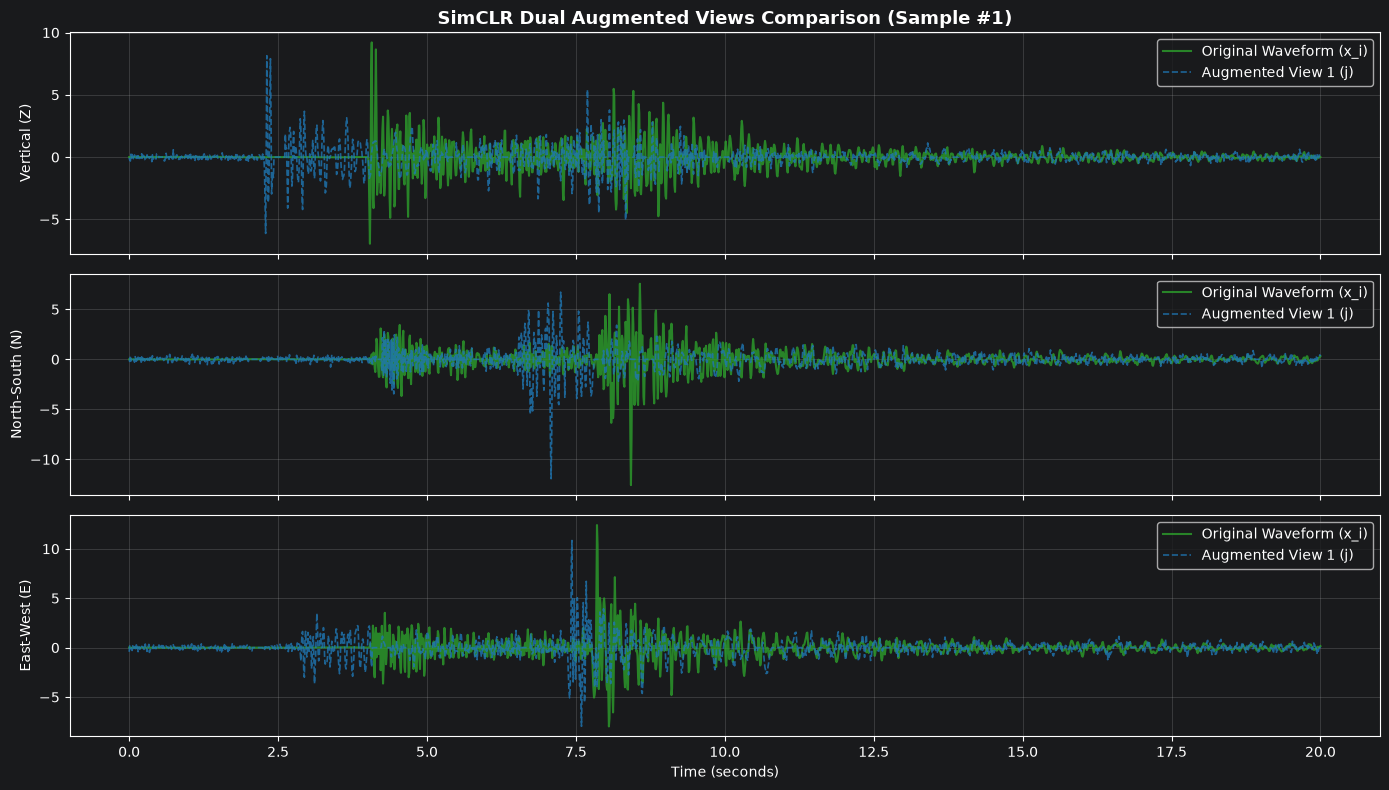

In [3]:
train_x, train_y = train_set()
sample_idx = np.where(train_y == 1)[0][0]
orig_sample = train_x[sample_idx]  # shape: (3, 2000)

augmenter = CustomAugmentation(
    n_speed_change=simCLR['n_speed_change'],
    max_speed_ratio=simCLR['max_speed_ratio'],
    scale=simCLR['noise_scale'],
    p=simCLR['probability_for_dropout']
)

# Generate two independent augmented views
view_1 = augmenter(orig_sample)

time_axis = np.linspace(0, 20.0, extractedSTEAD['n_length'])
channel_names = ['Vertical (Z)', 'North-South (N)', 'East-West (E)']

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for c in range(3):
    axes[c].plot(time_axis, orig_sample[c], label='Original Waveform (x_i)', color='#2ca02c', lw=1.5, alpha=0.8)
    axes[c].plot(time_axis, view_1[c], label='Augmented View 1 (j)', color='#1f77b4', lw=1.2, ls='--', alpha=0.8)
    axes[c].set_ylabel(channel_names[c])
    axes[c].legend(loc='upper right')
    axes[c].grid(True, alpha=0.3)

axes[0].set_title(f"SimCLR Dual Augmented Views Comparison (Sample #{sample_idx})", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

## 2. Initializing the SimCLR Architecture

The `SimCLR_Transformer` model consists of:
- **Transformer Encoder**: 6 multi-head self-attention layers with hidden dimension $512$ and $16$ attention heads.
- **Projection Head**: Linear $(3 \times 2000 \to 3000) \to$ ReLU $\to$ Linear $(3000 \to 512)$.

In [8]:
model = SimCLR_Transformer(
    projection_dim=simCLR['projection_dim'],
    n_channel=extractedSTEAD['n_channel'],
    n_length=extractedSTEAD['n_length'],
    n_layers=simCLR['n_layers'],
    n_hid=simCLR['n_hid'],
    n_head=simCLR['n_head'],
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"SimCLR Model Total Trainable Parameters: {total_params:,}")

SimCLR Model Total Trainable Parameters: 127,938,584


## 3. Loading Pretrained Weights or Running Demonstration Pretraining


In [9]:
TRAIN_DEMO_EPOCH = False  #  True to run 1 pretraining epoch

checkpoint_paths = [
    ROOT_DIR / "Models" / "Good Performing Model" / "simCLR_extractedSTEAD_6_512_16_512.tar",
]

ckpt_to_load = None
for cp in checkpoint_paths:
    if cp.exists():
        ckpt_to_load = cp
        break

if ckpt_to_load:
    print(f"Loading pretrained weights from: {ckpt_to_load.name}")
    model.load_state_dict(torch.load(str(ckpt_to_load), map_location=device))
    print("Pretrained weights loaded successfully!")
else:
    print("No pre-saved checkpoint found. Model initialized with random weights.")

# Optional 1-epoch pretraining demonstration
if TRAIN_DEMO_EPOCH:
    train_dataset = CustomTensorDataset(
        data=(train_x, train_y),
        transform_A=augmenter,
        transform_B=augmenter
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)
    criterion = NT_Xent(batch_size=128, temperature=simCLR['temperature'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=simCLR['lr'], weight_decay=simCLR['weight_decay'])
    model.train()
    losses = []
    for step, (x_i, x_j, _) in enumerate(train_loader):
        x_i, x_j = x_i.to(device), x_j.to(device)
        _, _, z_i, z_j = model(x_i, x_j)
        loss = criterion(z_i, z_j)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if step % 5 == 0:
            print(f"  Step [{step}/{len(train_loader)}]  NT-Xent Loss: {loss.item():.4f}")
    print(f"Demo Epoch Mean Loss: {np.mean(losses):.4f}")

Loading pretrained weights from: simCLR_extractedSTEAD_6_512_16_512.tar
Pretrained weights loaded successfully!


## 4. Latent Space Clustering & Evaluation

Let's evaluate the representation quality of the SimCLR Transformer encoder on the unseen test set.

We extract representations $h$ for each test sample, apply $L_2$-normalization, cluster with K-Means ($k=2$), and use the Hungarian algorithm to compute clustering performance.

In [11]:
test_x, test_y = test_set()

# Extract embeddings
embeddings = extract_embeddings(model, test_x, device, batch_size=128)
h_norm = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)

# K-Means Clustering
kmeans = KMeans(n_clusters=extractedSTEAD['n_class'], n_init=20, random_state=42)
cluster_labels = kmeans.fit_predict(h_norm)

# Compute Clustering Metrics
acc, cluster_labels_remapped = hungarian_accuracy(test_y, cluster_labels, extractedSTEAD['n_class'])
ari = adjusted_rand_score(test_y, cluster_labels)
nmi = normalized_mutual_info_score(test_y, cluster_labels)
sil = silhouette_score(h_norm, cluster_labels, sample_size=min(5000, len(test_y)))

print("=== SimCLR Latent Space Clustering Metrics ===")
print(f"  Clustering Accuracy (Hungarian): {acc:.4f} ({acc*100:.2f}%)")
print(f"  Adjusted Rand Index (ARI): {ari:.4f}")
print(f"  Normalized Mutual Info (NMI): {nmi:.4f}")
print(f"  Silhouette Score: {sil:.4f}")

=== SimCLR Latent Space Clustering Metrics ===
  Clustering Accuracy (Hungarian): 0.9067 (90.67%)
  Adjusted Rand Index (ARI): 0.6609
  Normalized Mutual Info (NMI): 0.5609
  Silhouette Score: 0.1917


## 5. 2D Manifold Visualizations (UMAP & t-SNE)

Let's project the SimCLR representations into 2D using UMAP and t-SNE to inspect cluster separation.

Computing UMAP 2D projection...


D:\Desktop\Intership IT\SSL&SeismicData\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing t-SNE 2D projection...


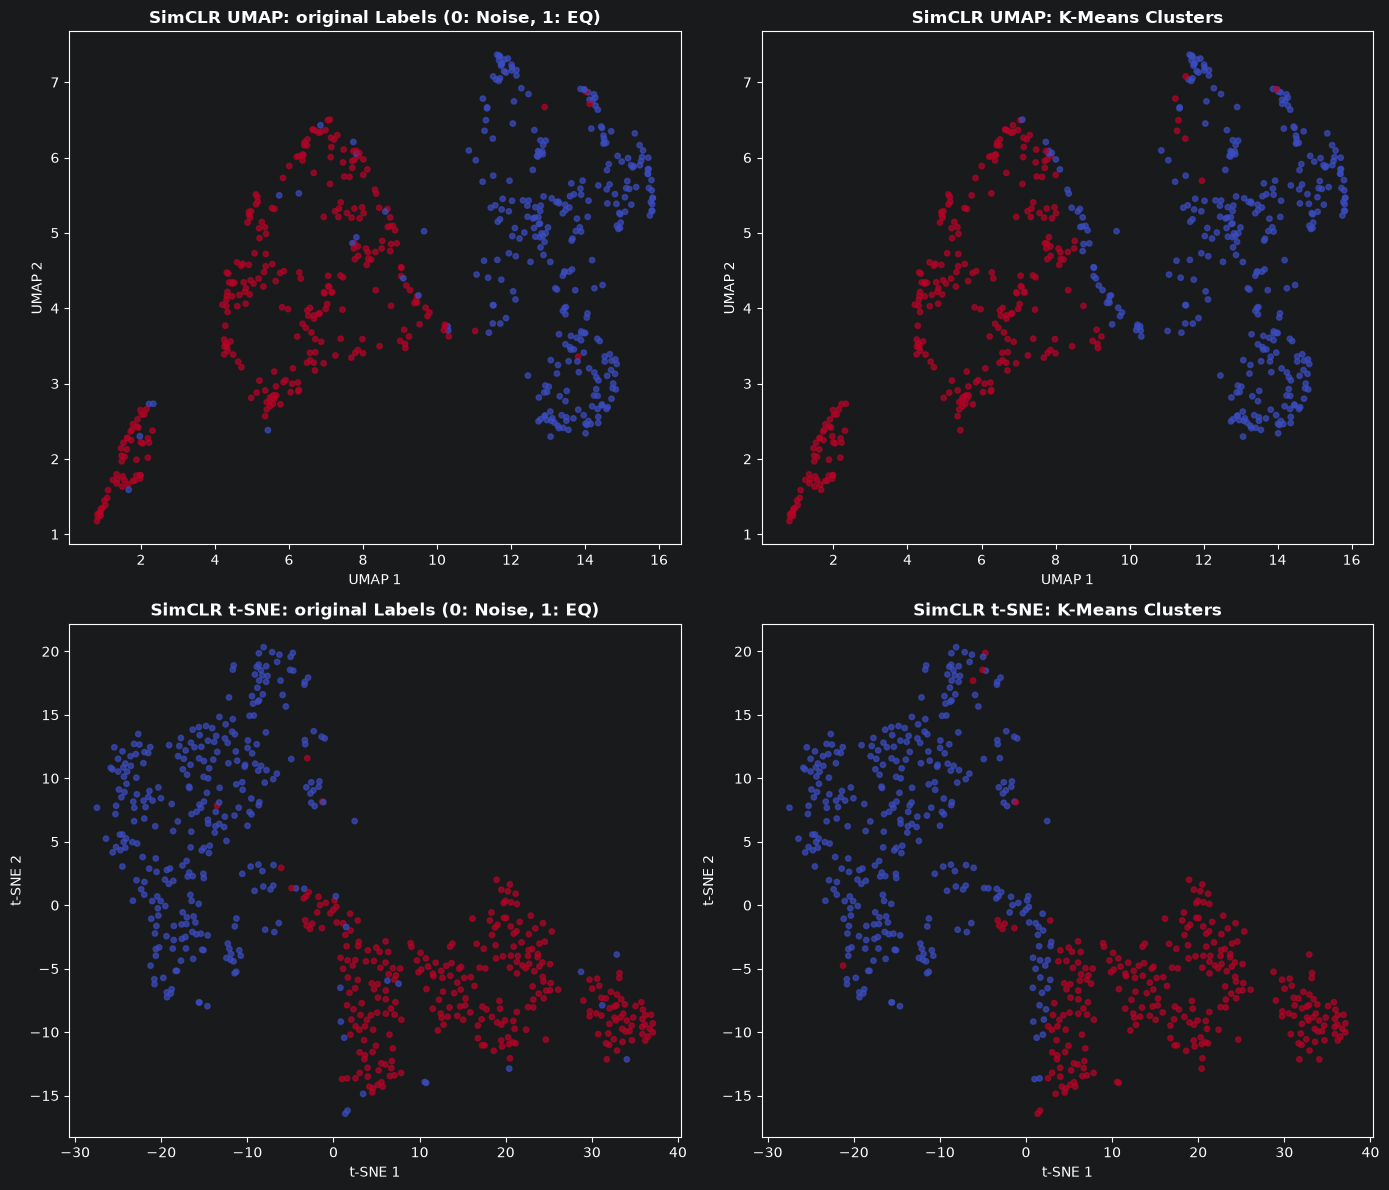

In [13]:
print("Computing UMAP 2D projection...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
umap_coords = reducer.fit_transform(h_norm)

print("Computing t-SNE 2D projection...")
tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1000)
tsne_coords = tsne.fit_transform(h_norm)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# UMAP colored by Ground Truth
axes[0, 0].scatter(umap_coords[:, 0], umap_coords[:, 1], c=test_y, cmap='coolwarm', alpha=0.7, s=15)
axes[0, 0].set_title("SimCLR UMAP: original Labels (0: Noise, 1: EQ)", fontweight='bold')
axes[0, 0].set_xlabel("UMAP 1")
axes[0, 0].set_ylabel("UMAP 2")

# UMAP colored by K-Means Clusters
axes[0, 1].scatter(umap_coords[:, 0], umap_coords[:, 1], c=cluster_labels_remapped, cmap='coolwarm', alpha=0.7, s=15)
axes[0, 1].set_title("SimCLR UMAP: K-Means Clusters", fontweight='bold')
axes[0, 1].set_xlabel("UMAP 1")
axes[0, 1].set_ylabel("UMAP 2")

# t-SNE colored by Ground Truth
axes[1, 0].scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=test_y, cmap='coolwarm', alpha=0.7, s=15)
axes[1, 0].set_title("SimCLR t-SNE: original Labels (0: Noise, 1: EQ)", fontweight='bold')
axes[1, 0].set_xlabel("t-SNE 1")
axes[1, 0].set_ylabel("t-SNE 2")

# t-SNE colored by K-Means Clusters
axes[1, 1].scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=cluster_labels_remapped, cmap='coolwarm', alpha=0.7, s=15)
axes[1, 1].set_title("SimCLR t-SNE: K-Means Clusters", fontweight='bold')
axes[1, 1].set_xlabel("t-SNE 1")
axes[1, 1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()